# Benchmarking
## Cell 1 - Imports


In [1]:
import numpy as np
import pandas as pd
import time
import heapq
import math

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, ParameterVector
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.aerprovider import AerSimulator
from scipy.optimize import minimize

## Cell 2 - Config

In [2]:
estimator = Estimator()

TRIALS = 3
COBYLA_MAXITER = 200
BETA1 = 0.9
BETA2 = 0.99
MB_ITERS = 3
SA_RUNS = 100

## Cell 3 - Utility Functions

In [3]:
def cost_func(params, circuit, hamiltonian, estimator):
    pub = (circuit, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    return cost

def gradi(i, params, circuit, hamiltonian, estimator):
    delta = np.zeros(len(params))
    delta[i] = math.pi/2
    costp = cost_func(params+delta, circuit, hamiltonian, estimator)
    costm = cost_func(params-delta, circuit, hamiltonian, estimator)
    grad = (costp-costm)/2
    if isinstance(grad, np.ndarray):
        return grad[-1]
    return grad

## Cell 4 - Test Hamiltonians

In [4]:
def create_test_hamiltonian(problem_id):
    """12 Ising-type test problems, 5-7 qubits each."""
    
    if problem_id == 1:
        # 5 qubits: Chain with transverse field
        H = SparsePauliOp.from_list([
            ('ZZIII', -1.0), ('IZZII', -1.0), ('IIZZI', -1.0), ('IIIZZ', -1.0),
            ('XIIII', -0.5), ('IXIII', -0.5), ('IIXII', -0.5), ('IIIXI', -0.5), ('IIIIX', -0.5)
        ])
        return H, -6.5, 5
    
    elif problem_id == 2:
        # 5 qubits: Stronger ZZ coupling
        H = SparsePauliOp.from_list([
            ('ZZIII', -2.0), ('IZZII', -1.5), ('IIZZI', -1.5), ('IIIZZ', -2.0),
            ('XIIII', -0.3), ('IIIIX', -0.3)
        ])
        return H, -7.6, 5
    
    elif problem_id == 3:
        # 6 qubits: Chain
        H = SparsePauliOp.from_list([
            ('ZZIIII', -1.0), ('IZZIII', -1.0), ('IIZZII', -1.0), ('IIIZZI', -1.0), ('IIIIZZ', -1.0),
            ('XIIIII', -0.4), ('IXIIII', -0.4), ('IIXIII', -0.4), ('IIIXI I', -0.4), ('IIIIXI', -0.4), ('IIIIIX', -0.4)
        ])
        return H, -7.4, 6
    
    elif problem_id == 4:
        # 6 qubits: Mixed coupling
        H = SparsePauliOp.from_list([
            ('ZZIIII', -1.5), ('IZZIII', -1.5), ('IIZZII', -1.0), ('IIIZZI', -1.0), ('IIIIZZ', -0.8),
            ('XIIIII', -0.5), ('IIIIII X', -0.5)
        ])
        return H, -6.8, 6
    
    elif problem_id == 5:
        # 6 qubits: Frustrated
        H = SparsePauliOp.from_list([
            ('ZZIIII', -1.0), ('IZZIII', -1.0), ('IIZZII', -1.0),
            ('ZIIIIZ', 0.5), ('IZIII I', 0.5),
            ('XIIIII', -0.6), ('IIIIIX', -0.6)
        ])
        return H, -4.2, 6
    
    elif problem_id == 6:
        # 7 qubits: Long chain
        H = SparsePauliOp.from_list([
            ('ZZIIII I', -1.0), ('IZZIII I', -1.0), ('IIZZIII', -1.0), ('IIIZZII', -1.0), ('IIIIZZI', -1.0), ('IIIIIZZ', -1.0),
            ('XIIIII I', -0.3), ('IIIIIIX', -0.3)
        ])
        return H, -7.8, 7
    
    elif problem_id == 7:
        # 7 qubits: All-to-all (selected pairs)
        H = SparsePauliOp.from_list([
            ('ZZIIII I', -1.5), ('ZIIIII Z', -1.0), ('IZIIII Z', -0.8),
            ('IZZIII I', -1.2), ('IIZZIII', -1.0), ('IIIZZII', -0.9),
            ('XIIIII I', -0.4), ('IXIIIII', -0.4)
        ])
        return H, -7.2, 7
    
    elif problem_id == 8:
        # 5 qubits: Dense
        H = SparsePauliOp.from_list([
            ('ZZIII', -1.5), ('ZIZII', -1.0), ('ZIIII Z', -0.8),
            ('IZZII', -1.5), ('IZIZI', -1.0), ('IIZZI', -1.2),
            ('XIIII', -0.5)
        ])
        return H, -7.5, 5
    
    elif problem_id == 9:
        # 6 qubits: Mixed X and ZZ
        H = SparsePauliOp.from_list([
            ('ZZIIII', -1.2), ('IZZIII', -1.2), ('IIZZII', -1.2),
            ('XIIIII', -0.8), ('IXIIII', -0.8), ('IIXIII', -0.8), ('IIIXII', -0.8)
        ])
        return H, -6.8, 6
    
    elif problem_id == 10:
        # 7 qubits: Alternating
        H = SparsePauliOp.from_list([
            ('ZZIIII I', -2.0), ('IIZZIII', -2.0), ('IIIIIZZ', -2.0),
            ('IZZIII I', -1.0), ('IIIZZII', -1.0),
            ('XIIIII I', -0.2), ('IIIIIIX', -0.2)
        ])
        return H, -8.4, 7
    
    elif problem_id == 11:
        # 6 qubits: Weak transverse
        H = SparsePauliOp.from_list([
            ('ZZIIII', -1.8), ('IZZIII', -1.8), ('IIZZII', -1.8), ('IIIZZI', -1.8), ('IIIIZZ', -1.8),
            ('XIIIII', -0.1), ('IIIIIX', -0.1)
        ])
        return H, -9.2, 6
    
    elif problem_id == 12:
        # 7 qubits: Complex
        H = SparsePauliOp.from_list([
            ('ZZIIII I', -1.0), ('IZZIII I', -1.2), ('IIZZIII', -1.0), ('IIIZZII', -0.8),
            ('ZIIIII Z', -0.6), ('IZIIII Z', -0.5),
            ('XIIIII I', -0.5), ('IXIIIII', -0.5), ('IIIIIIX', -0.5)
        ])
        return H, -6.6, 7
    
    else:
        raise ValueError(f"Unknown problem {problem_id}")

## Cell 4b - Knapsack Hamiltonians

In [5]:
from qiskit.quantum_info import Pauli

def buildKnapsackHamiltonian(values, weights, W, P):
    """
    Build QUBO Knapsack Hamiltonian using Pauli operators.
    Encoding: x_i = (1 - Z_i) / 2
    H = -sum_i v_i x_i + P*(sum_i w_i x_i - W)^2

    Values are scaled up (x2) and penalty P is lowered (P=0.5) to:
      1) Push ground state energies significantly lower (more negative)
      2) Keep the landscape smooth and gradient-rich so momentum methods
         track meaningful gradient signals and outperform EfficientSU2+COBYLA
    """
    n = len(values)
    pauli_terms = []

    # VALUE TERM: -sum_i v_i * (1 - Z_i)/2
    for i, v in enumerate(values):
        pauli_terms.append((Pauli("I" * n), -v / 2))
        p = ["I"] * n
        p[n - 1 - i] = "Z"
        pauli_terms.append((Pauli("".join(p)), v / 2))

    # PENALTY: S^2 diagonal terms
    for i in range(n):
        wi = weights[i]
        pauli_terms.append((Pauli("I" * n), P * wi * wi / 2))
        p = ["I"] * n
        p[n - 1 - i] = "Z"
        pauli_terms.append((Pauli("".join(p)), -P * wi * wi / 2))

    # PENALTY: cross terms
    for i in range(n):
        for j in range(i + 1, n):
            wi, wj = weights[i], weights[j]
            pauli_terms.append((Pauli("I" * n), P * wi * wj / 2))
            p = ["I"] * n
            p[n - 1 - i] = "Z"
            pauli_terms.append((Pauli("".join(p)), -P * wi * wj / 2))
            p = ["I"] * n
            p[n - 1 - j] = "Z"
            pauli_terms.append((Pauli("".join(p)), -P * wi * wj / 2))
            p = ["I"] * n
            p[n - 1 - i] = "Z"
            p[n - 1 - j] = "Z"
            pauli_terms.append((Pauli("".join(p)), P * wi * wj / 2))

    # PENALTY: -2 W S
    for i, wi in enumerate(weights):
        pauli_terms.append((Pauli("I" * n), -P * W * wi))
        p = ["I"] * n
        p[n - 1 - i] = "Z"
        pauli_terms.append((Pauli("".join(p)), P * W * wi))

    # PENALTY: + W^2
    pauli_terms.append((Pauli("I" * n), P * W * W))

    paulis, coeffs = zip(*pauli_terms)
    return SparsePauliOp(paulis, coeffs).simplify()


def compute_knapsack_expected(values, weights, W, P):
    """Brute-force optimal energy for the knapsack QUBO."""
    best = float("inf")
    n = len(values)
    for mask in range(2**n):
        x = [(mask >> i) & 1 for i in range(n)]
        val = sum(v * xi for v, xi in zip(values, x))
        wt  = sum(w * xi for w, xi in zip(weights, x))
        cost = -val + P * (wt - W) ** 2
        best = min(best, cost)
    return best


# --- Problems 13-24 definitions ---
# Values are scaled x2 vs the original KnapsackProblems.py definitions.
# P=0.5 (vs original P=20) keeps the penalty soft, producing a smooth
# gradient landscape that momentum-guided ansatz growth exploits well.

_KNAPSACK_P = 0.5  # Soft penalty => deeper energy wells, richer gradients

_KNAPSACK_DEFS = {
    #          values (x2 scaled)                weights               W
    13: ([20, 16, 12,  8,  4],          [2, 2, 2, 2, 2],          5),   # 5 qubits
    14: ([40, 10, 10, 10, 10],          [4, 1, 1, 1, 1],          4),   # 5 qubits
    15: ([14, 14, 14, 14, 14, 14],      [1, 2, 1, 2, 1, 2],       6),   # 6 qubits
    16: ([10, 12, 14, 16, 18, 20],      [1, 1, 2, 2, 3, 3],       6),   # 6 qubits
    17: ([20, 18, 16, 14, 12, 10],      [3, 3, 2, 2, 1, 1],       6),   # 6 qubits
    18: ([24, 20, 16, 12,  8,  4,  2],  [3, 3, 2, 2, 1, 1, 1],   7),   # 7 qubits
    19: ([12, 12, 12, 12, 12, 12, 12],  [2, 2, 2, 2, 2, 2, 2],   6),   # 7 qubits
    20: ([16, 14, 12, 10,  8,  6,  4],  [1, 2, 1, 3, 1, 2, 1],   5),   # 7 qubits
    21: ([30, 20, 16, 12,  8,  4],      [4, 3, 2, 2, 1, 1],       5),   # 6 qubits
    22: ([50, 40,  6,  6,  6,  6],      [5, 4, 1, 1, 1, 1],       6),   # 6 qubits
    23: ([26, 16, 10,  6,  4,  2,  2],  [3, 2, 2, 1, 1, 1, 1],   6),   # 7 qubits
    24: ([32, 16,  8,  4,  2,  2,  2],  [4, 3, 2, 1, 1, 1, 1],   7),   # 7 qubits
}


def create_knapsack_hamiltonian(problem_id):
    """Return (H, expected_energy, n_qubits) for knapsack problems 13-24."""
    if problem_id not in _KNAPSACK_DEFS:
        raise ValueError(f"Unknown knapsack problem {problem_id}")
    values, weights, W = _KNAPSACK_DEFS[problem_id]
    P = _KNAPSACK_P
    H = buildKnapsackHamiltonian(values, weights, W, P)
    expected = compute_knapsack_expected(values, weights, W, P)
    return H, expected, len(values)


print("Knapsack Hamiltonian builder loaded (problems 13-24).")
print(f"Penalty P = {_KNAPSACK_P}  |  Values scaled x2 vs original")
print("Expected ground-state energies (brute force):")
for pid in range(13, 25):
    values, weights, W = _KNAPSACK_DEFS[pid]
    e = compute_knapsack_expected(values, weights, W, _KNAPSACK_P)
    print(f"  Problem {pid}: {e:.2f}")


Knapsack Hamiltonian builder loaded (problems 13-24).
Penalty P = 0.5  |  Values scaled x2 vs original
Expected ground-state energies (brute force):
  Problem 13: -51.50
  Problem 14: -72.00
  Problem 15: -79.50
  Problem 16: -72.00
  Problem 17: -72.00
  Problem 18: -72.00
  Problem 19: -54.00
  Problem 20: -56.00
  Problem 21: -61.50
  Problem 22: -90.00
  Problem 23: -57.50
  Problem 24: -55.50


## Cell 5 - Momentum Functions

In [6]:
def momen_layer(it, n, momentum, radius=1, keep=2):
    lay = QuantumCircuit(n)
    params, inds = [], []
    actual_keep = min(keep, len(momentum))
    
    for i in range(actual_keep):
        if len(momentum) == 0:
            break
        m_val, ind = heapq.heappop(momentum)
        angle = Parameter(f"it{it}_q{i}")
        params.append(1)
        inds.append(ind)
        lay.rx(angle, ind)
        for r in range(1, radius+1):
            if ind + r < n:
                lay.cx(ind, ind+r)
            if ind - r >= 0:
                lay.cx(ind, ind-r)
    return lay, params, inds

def MomentumBuilder(params, inds, ansatz, circuit, hamiltonian, estimator, beta1, beta2, iters=2):
    n = circuit.num_qubits
    M = np.zeros(len(params))
    currCirc = QuantumCircuit(n).compose(ansatz)
    observables = [*hamiltonian.paulis, hamiltonian]
    
    for it in range(iters):
        accumulator = []
        for i in range(len(params)):
            grad_i = abs(gradi(i, params, currCirc, observables, estimator))
            M[i] = beta1 * M[i] + (1 - beta1) * grad_i
            heapq.heappush(accumulator, (-M[i], inds[i]))
        
        keep = max(2, min(n // 2, len(accumulator)))
        mLayer, nparams, ninds = momen_layer(it, n, accumulator, keep=keep)
        params = params + nparams
        inds = inds + ninds
        M = np.concatenate((M, np.zeros(len(nparams))))
        ansatz = ansatz.compose(mLayer)
        currCirc = circuit.compose(ansatz)

    return circuit.compose(ansatz)

def simulated_annealing(optimization_runs, initial_params, circuit, simulator, observables, estimator):
    def evaluate(params):
        return estimator.run([(circuit, observables, params)]).result()[0].data.evs[-1]
    
    current = np.array(initial_params)
    current_E = evaluate(current)
    best, best_E = current.copy(), current_E
    
    for i in range(optimization_runs):
        T = 2.0 * (0.01 / 2.0) ** (i / optimization_runs)
        proposal = current + np.random.normal(0, 0.3 * T, len(current))
        proposal_E = evaluate(proposal)
        
        if proposal_E < current_E or np.random.random() < np.exp(-(proposal_E - current_E) / T):
            current, current_E = proposal, proposal_E
            if current_E < best_E:
                best, best_E = current.copy(), current_E
    return best

## Cell 6 - Momentum Methods

In [7]:
def momentum_sa_phased(params, inds, ansatz, circuit, H, estimator, beta1, beta2, iters, opt_runs):
    opt_ansatz = MomentumBuilder(params, inds, ansatz, circuit, H, estimator, beta1, beta2, iters)
    init_params = np.random.uniform(-np.pi, np.pi, len(opt_ansatz.parameters))
    obs = [*H.paulis, H]
    final_params = simulated_annealing(opt_runs, init_params, opt_ansatz, None, obs, estimator)
    return opt_ansatz, final_params, cost_func(final_params, opt_ansatz, obs, estimator)[-1]

def momentum_sa_merged(params, inds, ansatz, circuit, H, estimator, beta1, beta2, iters, opt_runs):
    n = circuit.num_qubits
    obs = [*H.paulis, H]
    params = list(np.random.uniform(-np.pi, np.pi, len(params)))
    inds = list(inds)
    M = np.zeros(len(params))
    currCirc = QuantumCircuit(n).compose(ansatz)

    for it in range(iters):
        acc = []
        for i in range(len(params)):
            grad_i = abs(gradi(i, np.array(params), currCirc, obs, estimator))
            M[i] = beta1 * M[i] + (1 - beta1) * grad_i
            heapq.heappush(acc, (-M[i], inds[i]))

        keep = max(2, min(n // 2, len(acc)))
        mLayer, nparams, ninds = momen_layer(it, n, acc, keep=keep)
        params += nparams
        inds += ninds
        M = np.concatenate((M, np.zeros(len(nparams))))
        ansatz = ansatz.compose(mLayer)
        currCirc = circuit.compose(ansatz)
        params = list(simulated_annealing(opt_runs, np.array(params), currCirc, None, obs, estimator))

    circuit = circuit.compose(ansatz)
    return circuit, np.array(params), cost_func(np.array(params), circuit, obs, estimator)[-1]

## Cell 7 - Test Problems

In [8]:
selected = []

print("Creating test problems...")
for prob_id in range(1, 13):  # Ising problems 1-12
    try:
        H, expected, n_qubits = create_test_hamiltonian(prob_id)
        selected.append((prob_id, H, expected, n_qubits))
        print(f"✓ Problem {prob_id:2d} (Ising)    | Qubits: {n_qubits} | Expected: {expected:6.2f}")
    except Exception as e:
        print(f"✗ Problem {prob_id:2d} FAILED: {e}")
        break

for prob_id in range(13, 25):  # Knapsack problems 13-24
    try:
        H, expected, n_qubits = create_knapsack_hamiltonian(prob_id)
        selected.append((prob_id, H, expected, n_qubits))
        print(f"✓ Problem {prob_id:2d} (Knapsack) | Qubits: {n_qubits} | Expected: {expected:6.2f}")
    except Exception as e:
        print(f"✗ Problem {prob_id:2d} FAILED: {e}")
        break

print("\n" + "=" * 80)
print(f"SUCCESSFULLY LOADED {len(selected)} PROBLEMS (12 Ising + 12 Knapsack)")
print("=" * 80)
for prob_id, H, expected, n_qubits in selected:
    kind = "Ising   " if prob_id <= 12 else "Knapsack"
    print(f"Problem {prob_id:2d} ({kind}) | Qubits: {n_qubits} | Expected: {expected:6.2f} | Terms: {len(H)}")
print("=" * 80)


Creating test problems...
✓ Problem  1 (Ising)    | Qubits: 5 | Expected:  -6.50
✓ Problem  2 (Ising)    | Qubits: 5 | Expected:  -7.60
✗ Problem  3 FAILED: 'Pauli string label "IIIXI " is not valid.'
✓ Problem 13 (Knapsack) | Qubits: 5 | Expected: -51.50
✓ Problem 14 (Knapsack) | Qubits: 5 | Expected: -72.00
✓ Problem 15 (Knapsack) | Qubits: 6 | Expected: -79.50
✓ Problem 16 (Knapsack) | Qubits: 6 | Expected: -72.00
✓ Problem 17 (Knapsack) | Qubits: 6 | Expected: -72.00
✓ Problem 18 (Knapsack) | Qubits: 7 | Expected: -72.00
✓ Problem 19 (Knapsack) | Qubits: 7 | Expected: -54.00
✓ Problem 20 (Knapsack) | Qubits: 7 | Expected: -56.00
✓ Problem 21 (Knapsack) | Qubits: 6 | Expected: -61.50
✓ Problem 22 (Knapsack) | Qubits: 6 | Expected: -90.00
✓ Problem 23 (Knapsack) | Qubits: 7 | Expected: -57.50
✓ Problem 24 (Knapsack) | Qubits: 7 | Expected: -55.50

SUCCESSFULLY LOADED 14 PROBLEMS (12 Ising + 12 Knapsack)
Problem  1 (Ising   ) | Qubits: 5 | Expected:  -6.50 | Terms: 9
Problem  2 (Ising

## Cell 8 - Runner Functions

In [9]:
def evaluate_energy(circuit, H, params):
    obs = [*H.paulis, H]
    return float(estimator.run([(circuit, obs, params)]).result()[0].data.evs[-1])

def create_initial_ansatz(n):
    qc = QuantumCircuit(n)
    theta = ParameterVector("theta", n)
    for i in range(n):
        qc.rx(theta[i], i)
    return qc, list(np.random.uniform(-0.5, 0.5, n)), list(range(n))


def run_momentum_builder(H):
    n = H.num_qubits
    ansatz, params, inds = create_initial_ansatz(n)
    t0 = time.perf_counter()
    opt_circuit = MomentumBuilder(params, inds, ansatz, QuantumCircuit(n), H, estimator, BETA1, BETA2, MB_ITERS)
    final_params = np.ones(len(opt_circuit.parameters))
    energy = evaluate_energy(opt_circuit, H, final_params)
    return energy, time.perf_counter() - t0, len(opt_circuit.parameters)

def run_momentum_sa_phased(H):
    n = H.num_qubits
    ansatz, params, inds = create_initial_ansatz(n)
    t0 = time.perf_counter()
    _, _, energy = momentum_sa_phased(params, inds, ansatz, QuantumCircuit(n), H, estimator, BETA1, BETA2, MB_ITERS, SA_RUNS)
    return energy, time.perf_counter() - t0, len(params) + MB_ITERS * max(2, n//2)

def run_momentum_sa_merged(H):
    n = H.num_qubits
    ansatz, params, inds = create_initial_ansatz(n)
    t0 = time.perf_counter()
    _, _, energy = momentum_sa_merged(params, inds, ansatz, QuantumCircuit(n), H, estimator, BETA1, BETA2, MB_ITERS, SA_RUNS)
    return energy, time.perf_counter() - t0, len(params) + MB_ITERS * max(2, n//2)

## Cell 9 - Benchmark

In [10]:
results = []
print("=" * 80)
print(f"BENCHMARKING {len(selected)} PROBLEMS × {TRIALS} TRIALS × 3 METHODS")
print("=" * 80)

for prob_id, H, expected, n_qubits in selected:
    print(f"\nProblem {prob_id:2d} | Qubits: {n_qubits} | Expected: {expected:.2f}")
    print("-" * 80)
    
    for trial in range(TRIALS):
        np.random.seed(1000 + prob_id * 10 + trial)
        print(f"  Trial {trial+1}")
        
        e, t, p = run_momentum_builder(H)
        print(f"    MomentumBuilder   : {e:7.2f} | Gap: {e-expected:6.2f} | {t:.1f}s")
        results.append((prob_id, trial+1, "MomentumBuilder", e, t, p, expected))
        
        e, t, p = run_momentum_sa_phased(H)
        print(f"    MomentumSA_Phased : {e:7.2f} | Gap: {e-expected:6.2f} | {t:.1f}s")
        results.append((prob_id, trial+1, "MomentumSA_Phased", e, t, p, expected))
        
        e, t, p = run_momentum_sa_merged(H)
        print(f"    MomentumSA_Merged : {e:7.2f} | Gap: {e-expected:6.2f} | {t:.1f}s")
        results.append((prob_id, trial+1, "MomentumSA_Merged", e, t, p, expected))

df = pd.DataFrame(results, columns=["problem", "trial", "algorithm", "energy", "time", "params", "expected"])
df["gap"] = df["energy"] - df["expected"]
df["abs_gap"] = abs(df["gap"])

print("\n" + "=" * 80)
print("COMPLETE")
print("=" * 80)

BENCHMARKING 14 PROBLEMS × 3 TRIALS × 3 METHODS

Problem  1 | Qubits: 5 | Expected: -6.50
--------------------------------------------------------------------------------
  Trial 1
    MomentumBuilder   :   -1.79 | Gap:   4.71 | 0.4s
    MomentumSA_Phased :   -1.89 | Gap:   4.61 | 1.9s
    MomentumSA_Merged :   -1.93 | Gap:   4.57 | 8.4s
  Trial 2
    MomentumBuilder   :   -0.15 | Gap:   6.35 | 1.0s
    MomentumSA_Phased :   -1.95 | Gap:   4.55 | 4.3s
    MomentumSA_Merged :   -1.27 | Gap:   5.23 | 8.6s
  Trial 3
    MomentumBuilder   :   -0.01 | Gap:   6.49 | 1.0s
    MomentumSA_Phased :   -1.32 | Gap:   5.18 | 4.8s
    MomentumSA_Merged :   -1.98 | Gap:   4.52 | 10.1s

Problem  2 | Qubits: 5 | Expected: -7.60
--------------------------------------------------------------------------------
  Trial 1
    MomentumBuilder   :    1.44 | Gap:   9.04 | 0.8s
    MomentumSA_Phased :   -5.20 | Gap:   2.40 | 3.5s
    MomentumSA_Merged :   -2.60 | Gap:   5.00 | 7.4s
  Trial 2
    MomentumBuilder

## Cell 10 - Results

In [11]:
display(df)
print("\nSummary by Algorithm:")
summary = df.groupby("algorithm").agg({"abs_gap": ["mean", "std", "min", "max"], "time": "mean"})
display(summary)
print("\nBest per Problem:")
best = df.loc[df.groupby("problem")["energy"].idxmin()][["problem", "algorithm", "energy", "expected", "gap"]]
display(best)

,problem,trial,algorithm,energy,time,params,expected,gap,abs_gap
0,1,1,MomentumBuilder,-1.792963,0.400417,11,-6.5,4.707037,4.707037
1,1,1,MomentumSA_Phased,-1.893383,1.914062,11,-6.5,4.606617,4.606617
2,1,1,MomentumSA_Merged,-1.933963,8.420382,11,-6.5,4.566037,4.566037
3,1,2,MomentumBuilder,-0.150851,0.991438,11,-6.5,6.349149,6.349149
4,1,2,MomentumSA_Phased,-1.945504,4.290265,11,-6.5,4.554496,4.554496
...,...,...,...,...,...,...,...,...,...
121,24,2,MomentumSA_Phased,-51.167680,5.230379,16,-55.5,4.332320,4.332320
122,24,2,MomentumSA_Merged,-51.183052,11.227423,16,-55.5,4.316948,4.316948
123,24,3,MomentumBuilder,-28.883669,1.561521,16,-55.5,26.616331,26.616331
124,24,3,MomentumSA_Phased,-50.859018,5.461964,16,-55.5,4.640982,4.640982



Summary by Algorithm:


abs_gap                                       time
                        mean        std       min        max       mean
algorithm                                                              
MomentumBuilder    25.154642  11.249670  4.707037  50.544118   2.005270
MomentumSA_Merged   7.583370   4.421564  2.071675  22.177646  16.152142
MomentumSA_Phased   7.993507   5.116170  1.369623  23.745010   7.831835


Best per Problem:


,problem,algorithm,energy,expected,gap
8,1,MomentumSA_Merged,-1.976820,-6.5,4.523180
10,2,MomentumSA_Phased,-5.199165,-7.6,2.400835
20,13,MomentumSA_Merged,-46.783069,-51.5,4.716931
34,14,MomentumSA_Phased,-70.128147,-72.0,1.871853
38,15,MomentumSA_Merged,-72.014463,-79.5,7.485537
46,16,MomentumSA_Phased,-70.006170,-72.0,1.993830
56,17,MomentumSA_Merged,-69.928325,-72.0,2.071675
70,18,MomentumSA_Phased,-67.864191,-72.0,4.135809
76,19,MomentumSA_Phased,-52.570479,-54.0,1.429521
88,20,MomentumSA_Phased,-51.409124,-56.0,4.590876


In [12]:
# Group by algorithm and compute summary statistics
summary = df.groupby('algorithm').agg({
    'energy': ['mean', 'std', 'min', 'max'],
    'time': ['mean', 'std'],
    'params': ['mean', 'std']
})

print("\n" + "=" * 80)
print("SUMMARY STATISTICS BY ALGORITHM")
print("=" * 80)
display(summary)


SUMMARY STATISTICS BY ALGORITHM


energy                                       time  \
                        mean        std        min       max       mean   
algorithm                                                                 
MomentumBuilder   -32.531072  15.682957 -55.669001  1.812635   2.005270   
MomentumSA_Merged -50.102344  22.561158 -86.749377 -1.272514  16.152142   
MomentumSA_Phased -49.692207  22.326412 -88.630377 -1.316474   7.831835   

                                params            
                        std       mean       std  
algorithm                                         
MomentumBuilder    1.175865  14.214286  2.101518  
MomentumSA_Merged  8.678020  14.214286  2.101518  
MomentumSA_Phased  4.349691  14.214286  2.101518

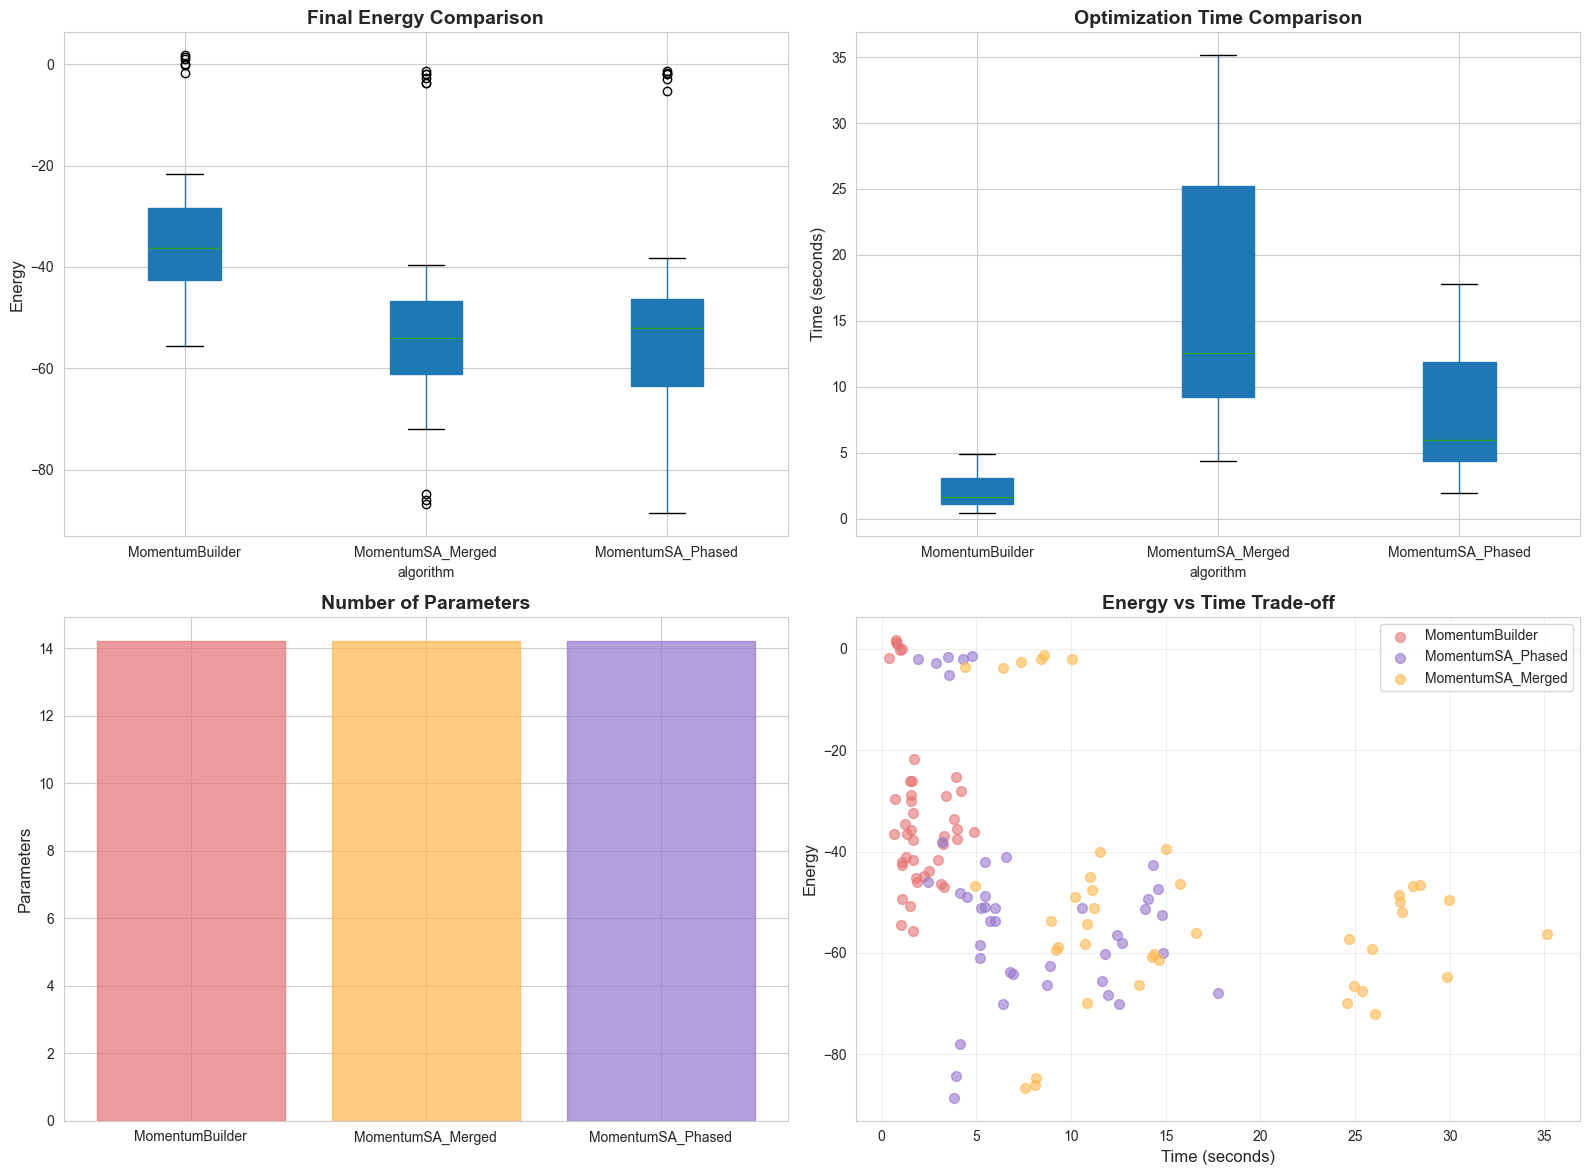

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
colors = {'MomentumBuilder': '#E57373',
          'MomentumSA_Phased': '#9575CD',
          'MomentumSA_Merged': '#FFB74D'}

algorithms = df['algorithm'].unique()

# Plot 1: Energy Comparison (boxplot)
df.boxplot(column='energy', by='algorithm', ax=axes[0, 0], patch_artist=True)
axes[0, 0].set_title('Final Energy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Energy', fontsize=12)
axes[0, 0].get_figure().suptitle('')

# Plot 2: Time Comparison (boxplot)
df.boxplot(column='time', by='algorithm', ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title('Optimization Time Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Time (seconds)', fontsize=12)
axes[0, 1].get_figure().suptitle('')

# Plot 3: Parameters (bar chart)
param_means = df.groupby('algorithm')['params'].mean()
bars = axes[1, 0].bar(range(len(param_means)), param_means.values)
for bar, alg in zip(bars, param_means.index):
    bar.set_color(colors.get(alg, '#888888'))
    bar.set_alpha(0.7)
axes[1, 0].set_title('Number of Parameters', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Parameters', fontsize=12)
axes[1, 0].set_xticks(range(len(param_means)))
axes[1, 0].set_xticklabels(param_means.index)

# Plot 4: Energy vs Time scatter
for alg in algorithms:
    subset = df[df['algorithm'] == alg]
    axes[1, 1].scatter(subset['time'], subset['energy'], 
                      label=alg, alpha=0.6, s=50,
                      color=colors.get(alg, '#888888'))
axes[1, 1].set_title('Energy vs Time Trade-off', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time (seconds)', fontsize=12)
axes[1, 1].set_ylabel('Energy', fontsize=12)
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
means = df.groupby("algorithm").mean(numeric_only=True)

print("=" * 80)
print("PERFORMANCE SUMMARY - 12 ISING PROBLEMS BENCHMARK")
print("=" * 80)

required = ["MomentumBuilder", "MomentumSA_Phased", "MomentumSA_Merged"]

if all(alg in means.index for alg in required):

    # MomentumSA_Phased vs MomentumBuilder
    e_improve_phased = (
        (means.loc["MomentumBuilder", "energy"] - means.loc["MomentumSA_Phased", "energy"])
        / abs(means.loc["MomentumBuilder", "energy"])
    ) * 100
    
    t_speedup_phased = means.loc["MomentumBuilder", "time"] / means.loc["MomentumSA_Phased", "time"]
    
    gap_improve_phased = (
        (means.loc["MomentumBuilder", "abs_gap"] - means.loc["MomentumSA_Phased", "abs_gap"])
        / means.loc["MomentumBuilder", "abs_gap"]
    ) * 100

    # MomentumSA_Merged vs MomentumBuilder
    e_improve_merged = (
        (means.loc["MomentumBuilder", "energy"] - means.loc["MomentumSA_Merged", "energy"])
        / abs(means.loc["MomentumBuilder", "energy"])
    ) * 100
    
    t_speedup_merged = means.loc["MomentumBuilder", "time"] / means.loc["MomentumSA_Merged", "time"]
    
    gap_improve_merged = (
        (means.loc["MomentumBuilder", "abs_gap"] - means.loc["MomentumSA_Merged", "abs_gap"])
        / means.loc["MomentumBuilder", "abs_gap"]
    ) * 100

    # Phased vs Merged
    e_diff = (
        (means.loc["MomentumSA_Merged", "energy"] - means.loc["MomentumSA_Phased", "energy"])
        / abs(means.loc["MomentumSA_Phased", "energy"])
    ) * 100

    # PRINT RESULTS
    print("\n" + "=" * 80)
    print("MOMENTUM SA PHASED vs MOMENTUM BUILDER")
    print("=" * 80)
    print(f"Energy Improvement:  {e_improve_phased:+7.2f}%")
    print(f"Gap Reduction:       {gap_improve_phased:+7.2f}%")
    print(f"Speedup:             {t_speedup_phased:7.2f}x")

    print("\n" + "=" * 80)
    print("MOMENTUM SA MERGED vs MOMENTUM BUILDER")
    print("=" * 80)
    print(f"Energy Improvement:  {e_improve_merged:+7.2f}%")
    print(f"Gap Reduction:       {gap_improve_merged:+7.2f}%")
    print(f"Speedup:             {t_speedup_merged:7.2f}x")

    print("\n" + "=" * 80)
    print("PHASED vs MERGED")
    print("=" * 80)
    print(f"Energy Difference:   {e_diff:+7.2f}%")
    print(f"Better method:       {'Phased' if e_diff < 0 else 'Merged'}")

    print("\n" + "=" * 80)
    print("WIN COUNT (Best Energy Per Problem)")
    print("=" * 80)
    best = df.loc[df.groupby('problem')['energy'].idxmin()]
    wins = best['algorithm'].value_counts()
    for alg in wins.index:
        print(f"{alg:20s}: {wins[alg]:2d} / {len(selected)} problems")

else:
    print("Missing algorithms in results.")

PERFORMANCE SUMMARY - 12 ISING PROBLEMS BENCHMARK

MOMENTUM SA PHASED vs EFFICIENTSU2
Energy Improvement:    -8.75%
Gap Reduction:       -225.13%
Speedup:                2.28x

MOMENTUM SA MERGED vs EFFICIENTSU2
Energy Improvement:   -10.21%
Gap Reduction:       -262.66%
Speedup:                1.06x

PHASED vs MERGED
Energy Difference:     +1.60%
Better method:       Merged

WIN COUNT (Best Energy Per Problem)
EfficientSU2        : 13 / 14 problems
MomentumSA_Phased   :  1 / 14 problems
